In [ ]:
# ETAPE 2: PRETRAITEMNT
#netoyage de base

In [ ]:
twifil_copy = twifil.copy()

In [ ]:
# remove url
def remove_urls(text):
    return re.sub(r"http\S+|www\S+|https\S+", "", str(text))

twifil_copy["clean_text"] = twifil_copy["Post"].apply(remove_urls)


In [ ]:
#remove mention
def remove_mentions(text):
    return re.sub(r"@\w+", "", text)

twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(remove_mentions)


In [ ]:
#convert emojies
def convert_emojis(text):
    return emoji.demojize(text)

twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(convert_emojis)


In [ ]:
# supprimer les doublants
twifil_copy= twifil_copy.drop_duplicates(subset=["clean_text"])


In [ ]:
#supprimer les tweet vides
twifil_copy = twifil_copy[twifil_copy["clean_text"].str.strip() != ""]
#supprimer nan
twifil_copy = twifil_copy[twifil_copy["clean_text"].notna()]
#supprimer inutile text
twifil_copy["clean_text"] = twifil_copy["clean_text"].str.strip()
def is_useful_text(text):
    """
    Vérifie si un texte contient du contenu utile pour l'analyse de sentiment
    Garde les tweets avec emojis car ils expriment des émotions
     # si le texte est vide ou sans contenu significatif il retourne false
    """
    if pd.isna(text):
        return False

    text = str(text).strip()

    if text == "":
        return False

    # Compter les emojis convertis
    emoji_pattern = re.compile(r':[a-z_]+:')
    emojis = emoji_pattern.findall(text)

    # Enlever les emojis pour vérifier le reste du texte
    text_without_emoji = emoji_pattern.sub('', text)
    text_without_emoji = text_without_emoji.strip()

    # Enlever les chiffres et ponctuations pour ne garder que les mots
    words_only = re.sub(r'[\d\W_]+', ' ', text_without_emoji)
    words_only = ' '.join(words_only.split())

    # Garder le tweet si:
    # - Il a au moins un mot (même court) OU
    # - Il a au moins un emoji
    has_words = len(words_only) > 1
    has_emojis = len(emojis) >= 1

    return has_words or has_emojis
twifil_copy = twifil_copy[twifil_copy["clean_text"].apply(is_useful_text)]


In [ ]:
#2.2 Normalisation spécifique au darija

In [ ]:
def normalize_repeated_letters(text):
    # Arabic letters repetition
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text

twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(normalize_repeated_letters)


In [ ]:
def normalize_numbers(text):
    eastern_to_western = str.maketrans(
        "٠١٢٣٤٥٦٧٨٩",
        "0123456789"
    )
    return text.translate(eastern_to_western)

twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(normalize_numbers)


In [ ]:
# amelioration en plus

In [ ]:
# remove hashtag
def normalize_hashtags(text):
        text = re.sub(r'#(\w+)', r'\1', text)
        return text
twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(normalize_hashtags)


In [ ]:
    #Supprimer les caractères de contrôle et autres caractères non imprimables
def remove_non_printable(text):
       text = ''.join(char for char in text if char.isprintable())
       return text
twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(remove_non_printable)


In [ ]:
  #  Supprimer les chaînes de caractères sans valeur sentimentale
def clean_noise_strings(text):
    if pd.isna(text):
        return text

    text = str(text)

    # 1. Supprimer les hashs(32, 40, 64 caractères hexadécimaux)
    text = re.sub(r'\b[0-9a-f]{32}\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b[0-9a-f]{40}\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b[0-9a-f]{64}\b', '', text, flags=re.IGNORECASE)

    # 2. Supprimer les UUID
    uuid_pattern = r'\b[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}\b'
    text = re.sub(uuid_pattern, '', text, flags=re.IGNORECASE)

    # 3. Supprimer les chaînes qui ressemblent à des tokens techniques
    # (mélange de lettres, chiffres, underscores, points)
    text = re.sub(r'\b[a-zA-Z0-9._]{25,}\b', '', text)

    # 4. Supprimer les chaînes qui n'ont pas de voyelles (probablement du bruit)
    # On applique seulement sur les chaînes > 15 caractères
    def has_vowels(word):
        return bool(re.search(r'[aeiouAEIOU]', word))

    words = text.split()
    filtered_words = []
    for word in words:
        # Garder si: court (<15) OU a des voyelles OU a de l'arabe
        if len(word) < 15 or has_vowels(word) or re.search(r'[\u0600-\u06FF]', word):
            filtered_words.append(word)

    text = ' '.join(filtered_words)

    # 5. Nettoyer les espaces
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text
twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(clean_noise_strings)


In [ ]:
#normalize repeated emojis
def normalize_repeated_emojis(text):

    if pd.isna(text):
        return text

    text = str(text)

    emoji_pattern = r'(:[a-z_]+:)\1+'

    def replace_with_count(match):
        emoji = match.group(1)
        full_match = match.group(0)
        count = full_match.count(emoji)

        if count > 1:
            return f"{emoji}_x{count}"
        return emoji

    text = re.sub(emoji_pattern, replace_with_count, text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text
twifil_copy["clean_text"]= twifil_copy["clean_text"].apply(normalize_repeated_emojis)

In [ ]:

twifil_copy[["Post", "clean_text"]].sample(10)


,Post,clean_text
3470,@MOU_st6 يا اخي جمال محترم يلزم نتعلم كل واحد ...,يا اخي جمال محترم يلزم نتعلم كل واحد يعطي رايه...
656,@davidbisbal @Twitter Felicidades Gran Artista...,Felicidades Gran Artista Te Lo Mereces :thumbs...
5789,@kasimf انها الاستخبارات الامريكية,انها الاستخبارات الامريكية
5342,"Ne vous attachez jamais trop à quelqu'un, sauf...","Ne vous attachez jamais trop à quelqu'un, sauf..."
3430,Hazaaaaaaard ✌\n#CHELIV,Hazaard :victory_hand:CHELIV
1861,😍🤣,:smiling_face_with_heart-eyes:::
325,just ate a 12 pack of sausages massive protein...,just ate a 12 pack of sausages massive protein...
4441,@DoctorNene Now here in Algeria 🇩🇿 city tiziou...,Now here in Algeria :Algeria: city tiziouzou i...
3971,@Sindrilla7 و ان تعدوا نعمة الله لا تحصوها \nو...,و ان تعدوا نعمة الله لا تحصوها و ان نرضى بما ق...
1546,@BlackPinkyWho @livemalikhadid @gossipseriesfr...,Bonjour


In [ ]:
und_tweets = twifil_copy[twifil_copy["lang"] == "und"]
print("Number of 'und' tweets:", len(und_tweets))
und_tweets["clean_text"].sample(10)


Number of 'und' tweets: 378


,clean_text
2902,:slightly_smiling_face:_x10
3361,":globe_showing_Asia-Australia: (23.906585, 1.7..."
4180,صور | 180930شينبي في برنامج King Of Masked Sin...
869,souhilaBenLachhab souhilabenlachhab
1732,Wow
338,Mag: 3.4 - Depth: 10 km - UTC 10:05 AM - North...
5058,RIP
4147,:smiling_face_with_heart-eyes:
2098,:red_heart:_x2:Canada::Canada::red_heart:_x2
113,hh


In [ ]:
und_analysis = und_tweets["detected_lang"].value_counts()
und_analysis


,count
detected_lang,
French/Latin,195
Arabizi,109
Code-switch,64
Other,8
Arabic,2


In [ ]:
# tweet len
twifil_copy["tweet_length"] = twifil_copy["clean_text"].apply(lambda x: len(str(x).split()))
short_tweets = twifil_copy[twifil_copy["tweet_length"] <= 2]

print("Number of very short tweets:", len(short_tweets))
print("Percentage:", (len(short_tweets) / len(twifil_copy)) * 100)


Number of very short tweets: 842
Percentage: 16.90084303492573


In [ ]:
#short tweets par class
sentiment_counts =short_tweets["Polarity Class"].value_counts()
sentiment_counts

,count
Polarity Class,
Positive,530
Neutral,183
Negative,129


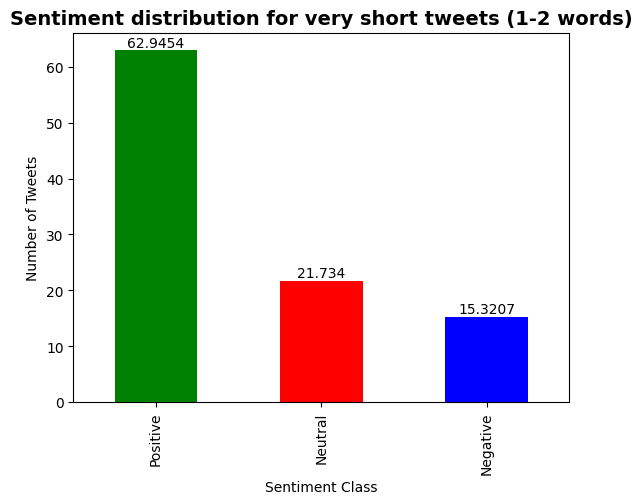

In [ ]:
#visualisation by barchar
sentiment_percentage = short_tweets["Polarity Class"].value_counts(normalize=True) * 100

ax=sentiment_percentage.plot(kind="bar")
# Define the colors
bar_colors = ['green', 'red', 'blue']

# Set the colors for each bar
for i, bar in enumerate(ax.patches):
    bar.set_facecolor(bar_colors[i % len(bar_colors)])
plt.title("Sentiment distribution for very short tweets (1-2 words)" ,fontsize=14 , fontweight="bold")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Tweets")
for container in ax.containers:
    ax.bar_label(container)
plt.show()


In [ ]:
twifil_copy.shape

(4982, 23)

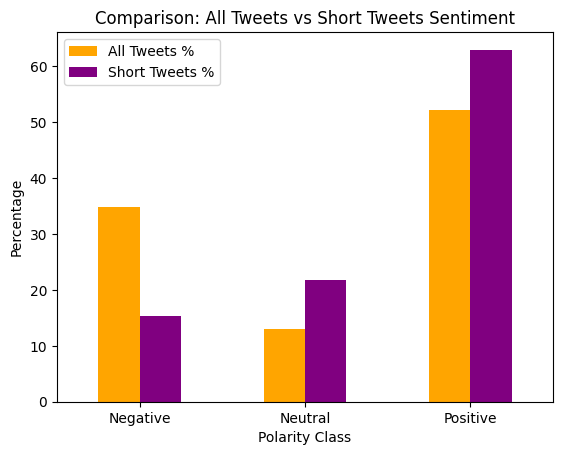

In [ ]:
#comparaison between short and all tweets
all_counts = twifil_copy["Polarity Class"].value_counts(normalize=True) * 100
short_counts = short_tweets["Polarity Class"].value_counts(normalize=True) * 100

comparison = pd.DataFrame({
    "All Tweets %": all_counts,
    "Short Tweets %": short_counts
})

comparison.plot(kind="bar", color=['orange','purple'])
plt.title("Comparison: All Tweets vs Short Tweets Sentiment")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


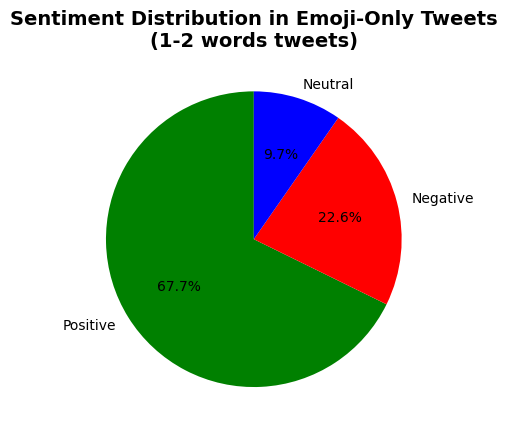


Statistiques des tweets avec seulement des emojis:
Nombre total: 31


In [ ]:
#visualisation des short tweets that has only emojies
# Identifier les tweets avec seulement des emojis
def has_only_emojis(text):
    if pd.isna(text):
        return False
    text = str(text).strip()
    emoji_pattern = re.compile(r'^(:[a-z_]+:\s*)+$')
    return bool(emoji_pattern.match(text))

emoji_only_tweets = twifil_copy[twifil_copy["clean_text"].apply(has_only_emojis)]

# Pie chart
if len(emoji_only_tweets) > 0:
    emoji_sentiment = emoji_only_tweets["Polarity Class"].value_counts(normalize=True) * 100

    wedges, texts, autotexts = plt.pie(
        emoji_sentiment.values,
        labels=emoji_sentiment.index,
        colors=['green', 'red', 'blue'],
        autopct='%1.1f%%',
        startangle=90,
    )

    plt.title("Sentiment Distribution in Emoji-Only Tweets\n(1-2 words tweets)",
              fontsize=14, fontweight="bold")
    plt.show()

    # Afficher les statistiques
    print("\nStatistiques des tweets avec seulement des emojis:")
    print(f"Nombre total: {len(emoji_only_tweets)}")


In [ ]:
#verifier l'absebce des val innatendues
twifil_copy["Polarity Class"].value_counts()


,count
Polarity Class,
Positive,2596
Negative,1736
Neutral,650


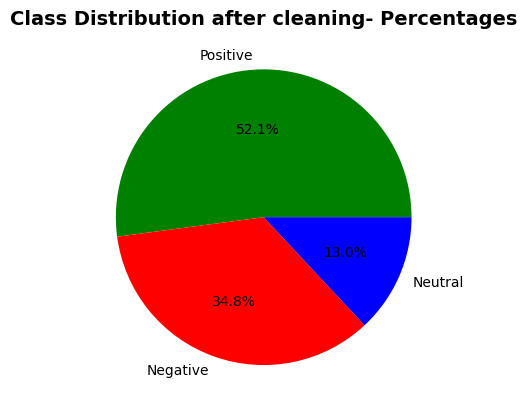

In [ ]:
# Pie Chart
twifil_copy['Polarity Class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['green','red','blue'])

plt.title("Class Distribution after cleaning- Percentages",fontsize=14, fontweight="bold")
plt.ylabel('')
plt.show()